# Data import

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Data exploration

In [ ]:
# Load the dataset
infile = "https://raw.githubusercontent.com/cgenomicslab/Courses/refs/heads/main/MScNeuro/2026/data/mouse_cognition.csv"
#infile = "/Users/alxndrs/Documents/courses/Courses/MScNeuro/2026/data/mouse_cognition.csv"
mice = pd.read_csv(infile)

mice.head(100)

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,M096,G,76,72,64,69,7.9,6.6,5.7,7.2,enriched,12,no,15,32.5
96,M097,G,68,64,56,61,7.1,5.8,6.3,6.4,high_fat,12,no,10,33.2
97,M098,G,74,70,62,67,7.7,6.4,5.8,7.0,standard,12,no,13,31.4
98,M099,G,77,73,65,70,8.0,6.7,5.6,7.3,enriched,12,no,14,31.8


Question 6  
Does diet affect fear conditioning? (standard vs high_fat)

In [ ]:
mice_fc = mice[mice['diet'].isin(['standard', 'high_fat'])][ ['diet', 'fear_conditioning']].dropna()
mice_fc['diet'].value_counts()

,count
diet,
standard,64
high_fat,24


In [ ]:
mice_fc.groupby('diet')['fear_conditioning'].describe()

,count,mean,std,min,25%,50%,75%,max
diet,,,,,,,,
high_fat,24.0,64.583333,8.086041,50.0,60.25,65.0,68.5,80.0
standard,64.0,68.546875,8.160940,52.0,62.75,69.0,73.0,85.0


## Visualization
Fear conditioning scores for animals fed a standard diet versus a high-fat diet.

<Figure size 640x480 with 0 Axes>

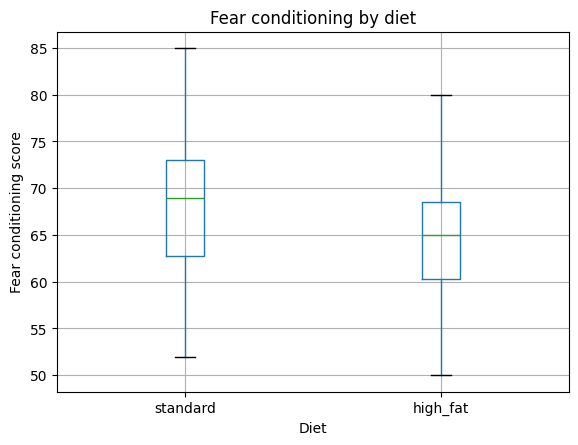

In [ ]:
plt.figure()
mice_fc['diet'] = pd.Categorical(mice_fc['diet'], categories=['standard', 'high_fat'], ordered=True)
mice_fc.boxplot(column='fear_conditioning', by='diet')
plt.title('Fear conditioning by diet')
plt.suptitle('')
plt.ylabel('Fear conditioning score')
plt.xlabel('Diet')
plt.show()

## Statistical Analysis
Analyses were restricted to standard and high-fat diet groups, as specified in the assignment.



In [ ]:
standard = mice_fc[mice_fc['diet'] == 'standard']['fear_conditioning']
high_fat = mice_fc[mice_fc['diet'] == 'high_fat']['fear_conditioning']

In [ ]:
stats.shapiro(standard)

ShapiroResult(statistic=np.float64(0.9797273640681758), pvalue=np.float64(0.3736422425238644))

In [ ]:
stats.shapiro(high_fat)

ShapiroResult(statistic=np.float64(0.9704939421570371), pvalue=np.float64(0.6791979074515035))

The Shapiro–Wilk test was used to assess normality of fear conditioning scores in each diet group. Neither group significantly deviated from a normal distribution (p > 0.05), indicating approximate normality. Therefore, a t-test was used to compare fear conditioning between diet groups.

In [ ]:
stats.ttest_ind(standard, high_fat,equal_var=False)

TtestResult(statistic=np.float64(2.04268948022633), pvalue=np.float64(0.04743774607235372), df=np.float64(41.70536904538271))

# Interpretation

We tested whether diet affects fear conditioning by comparing animals fed a standard diet to those fed a high-fat diet.The t-test revealed a significant difference in fear conditioning between the two groups (p < 0.05), suggesting that dietary composition may influence fear-related learning and memory processes.